# Modelagem, Avaliação e Interpretabilidade

Este notebook apresenta a etapa de modelagem, avaliação e interpretabilidade da solução proposta para classificação de indicativo de diabetes. O objetivo é comparar modelos, selecionar a alternativa com melhor desempenho no contexto do problema e interpretar os principais sinais utilizados na predição.

## 1. Carregamento e preparação da base


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')

In [14]:
DATA_PATH = '../dataset/diabetes.csv'
df = pd.read_csv(DATA_PATH)

X = df.drop(columns='Outcome').copy()
y = df['Outcome']

zero_suspect_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[zero_suspect_cols] = X[zero_suspect_cols].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape

((614, 8), (154, 8))

Nesta etapa, a base foi novamente preparada para garantir reprodutibilidade da modelagem e da avaliação. Foram reaplicados o tratamento dos zeros clinicamente suspeitos como valores ausentes e a divisão estratificada entre treino e teste.

## 2. Pipeline de pré-processamento e modelos


In [15]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42)
}

model_pipelines = {
    name: Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}

model_pipelines

{'LogisticRegression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Pregnancies', 'Glucose',
                                                    'BloodPressure',
                                                    'SkinThickness', 'Insulin',
                                                    'BMI',
                                                    'DiabetesPedigreeFunction',
                                                    'Age'])])),
                 ('model', LogisticRegression(max_iter=1000, random_state=42))]),
 'RandomForest': Pipeline

Foram selecionados dois modelos com perfis complementares: `LogisticRegression`, como baseline interpretável, e `RandomForest`, como modelo mais robusto a relações não lineares em dados tabulares. Ambos foram encapsulados em pipelines com o mesmo pré-processamento para garantir comparabilidade justa.

## 3. Treinamento e previsões


In [16]:
trained_models = {}
predictions = {}

for name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    predictions[name] = pipeline.predict(X_test)

list(trained_models.keys())

['LogisticRegression', 'RandomForest']

Os modelos foram treinados utilizando o conjunto de treino, com pré-processamento encapsulado nos pipelines. Em seguida, foram geradas previsões no conjunto de teste, preservando a mesma lógica metodológica para ambos os algoritmos.

## 4. Métricas finais


In [17]:
evaluation_results = []

for name, y_pred in predictions.items():
    evaluation_results.append({
        'modelo': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(evaluation_results).sort_values(by='f1_score', ascending=False)
results_df.to_csv('../results/metricas-modelos.csv', index=False)
results_df

,modelo,accuracy,recall,f1_score
1,RandomForest,0.77,0.61,0.65
0,LogisticRegression,0.71,0.50,0.55


A comparação das métricas mostra que o RandomForest apresentou melhor desempenho do que a `LogisticRegression` em `accuracy`, `recall` e `f1_score`. O ganho em `recall` foi considerado especialmente relevante, pois reduz o risco de deixar de identificar pacientes com indicativo de diabetes.

## 5. Escolha do modelo principal


In [18]:
final_model_name = 'RandomForest'
final_model = trained_models[final_model_name]
final_predictions = predictions[final_model_name]

final_model_name

'RandomForest'

Com base nos resultados obtidos, o modelo `RandomForest` foi escolhido como principal para o problema. Em comparação com a `LogisticRegression`, ele apresentou melhor equilíbrio entre desempenho global e capacidade de identificar corretamente casos positivos, o que o torna mais adequado ao contexto da aplicação proposta.

## 6. Matriz de confusão


In [19]:
cm = confusion_matrix(y_test, final_predictions)
cm

array([[86, 14],
       [21, 33]])

In [20]:
confusion_summary = pd.DataFrame({
    'true_negative': [cm[0, 0]],
    'false_positive': [cm[0, 1]],
    'false_negative': [cm[1, 0]],
    'true_positive': [cm[1, 1]]
})

confusion_summary.to_csv('../results/matriz-confusao-randomforest.csv', index=False)

confusion_summary

,true_negative,false_positive,false_negative,true_positive
0,86,14,21,33


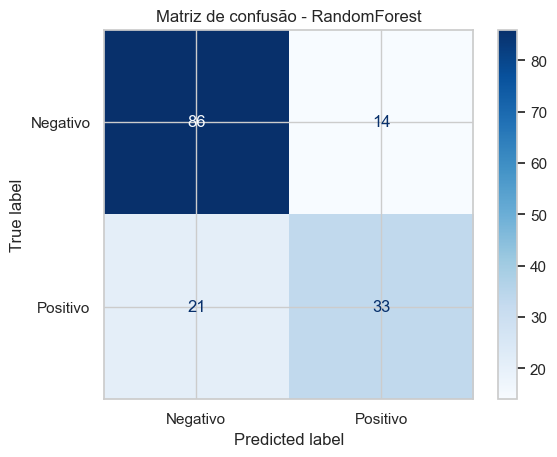

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Positivo'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusão - RandomForest')
plt.savefig('../figures/matriz-confusao-randomforest.png', bbox_inches='tight', dpi=300)
plt.show()

A matriz de confusão mostra que o modelo `RandomForest` apresentou bom equilíbrio entre acertos e erros, com redução de falsos negativos em relação ao baseline. Esse ponto é especialmente importante no contexto do problema, pois deixar de identificar um paciente potencialmente positivo representa um erro mais sensível.

## 7. Importância das variáveis


In [22]:
feature_importances = pd.DataFrame({
    'variavel': X.columns,
    'importancia': final_model.named_steps['model'].feature_importances_
}).sort_values(by='importancia', ascending=False)
feature_importances.to_csv('../results/importancia-variaveis-randomforest.csv', index=False)
feature_importances

,variavel,importancia
1,Glucose,0.27
5,BMI,0.16
6,DiabetesPedigreeFunction,0.12
7,Age,0.11
4,Insulin,0.09
2,BloodPressure,0.08
0,Pregnancies,0.08
3,SkinThickness,0.07


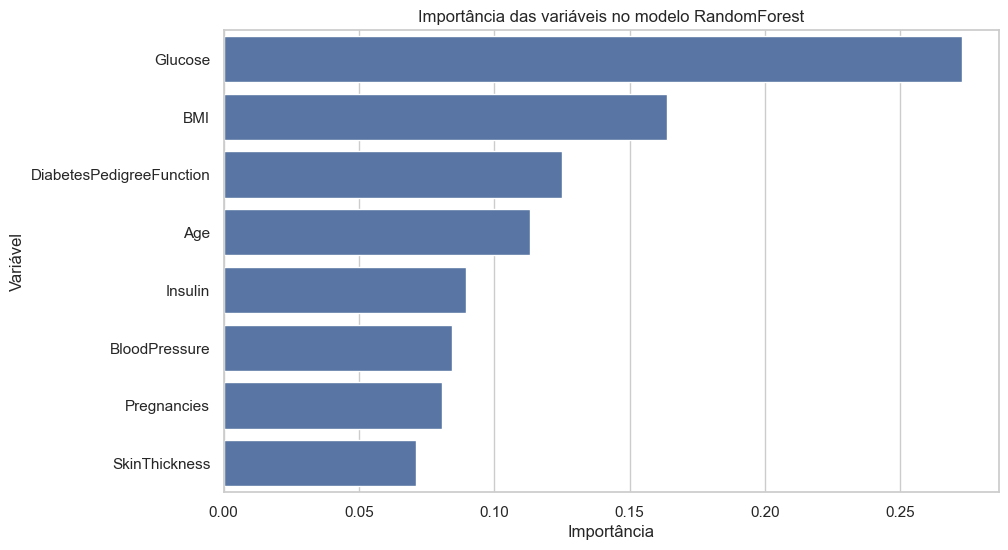

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='importancia', y='variavel')
plt.title('Importância das variáveis no modelo RandomForest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.savefig('../figures/importancia-variaveis-randomforest.png', bbox_inches='tight', dpi=300)
plt.show()

A análise de importância das variáveis mostra que `Glucose` foi o atributo mais relevante para o modelo final, seguida por `BMI`, `DiabetesPedigreeFunction` e `Age`. Esse resultado é coerente com os achados da análise exploratória, especialmente no destaque anterior de `Glucose` e `BMI`.

## 8. Interpretabilidade com SHAP


<Figure size 640x480 with 0 Axes>

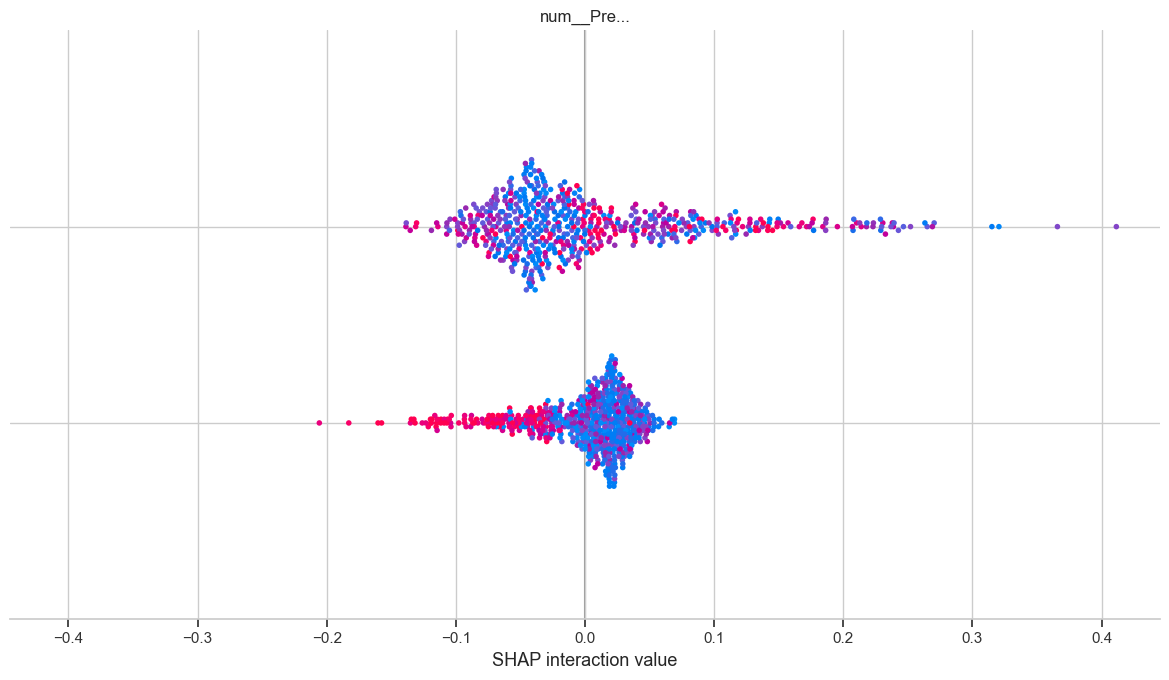

In [27]:
X_train_transformed = final_model.named_steps['preprocessor'].transform(X_train)
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
rf_model = final_model.named_steps['model']

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names, show=False)
plt.savefig('../figures/shap-summary-randomforest.png', bbox_inches='tight', dpi=300)
plt.show()

A análise com SHAP complementa a importância global das variáveis ao mostrar como os atributos contribuem para as previsões do modelo. Essa leitura ajuda a verificar se o comportamento do `RandomForest` se apoia em sinais compatíveis com o contexto clínico discutido nas etapas anteriores.

## 9. Conclusão


O modelo RandomForest apresentou o melhor equilíbrio entre desempenho global e capacidade de identificar corretamente casos positivos. A análise de interpretabilidade confirmou a relevância de variáveis como `Glucose`, `BMI` e `Age`, em coerência com os achados da etapa exploratória. Considerando o contexto do problema, o uso mais adequado da solução é como apoio à triagem e à priorização de casos, e não como substituição da decisão médica.